In [12]:
import happybase
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [9]:
# 1. Connection
connection = happybase.Connection(host='hbase')
table = connection.table('crypto_index_aggregates')

In [10]:
# 2. Fetch data (Simulating filtered_crypto_specific)
data = []
# Change symbol here to test BTC, ETH, or SOL
target_symbol = "BTC" 

for key, value in table.scan(row_prefix=f"{target_symbol}#".encode()):
    parts = key.decode().split('#')
    if len(parts) == 3:
        symbol, timestamp, granularity = parts
        # The distribution plot specifically needs high-frequency data (1m)
        if granularity == '1m':
            data.append({
                'Datetime': pd.to_datetime(timestamp),
                'Close': value.get(b'ohlc:close')
            })

connection.close()

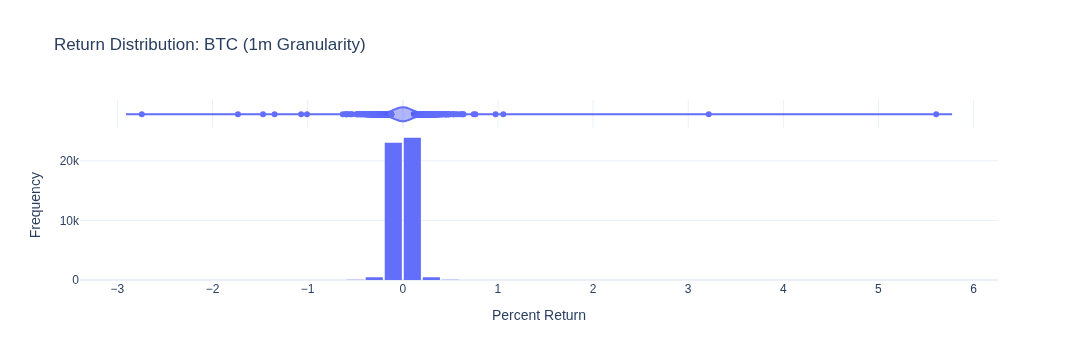

In [13]:
# 3. Data Processing & Troubleshooting
df = pd.DataFrame(data)

if df.empty:
    print(f"Error: No '1m' data found for {target_symbol}. Check your row keys in HBase.")
else:
    # Decode bytes to strings and convert to float
    df['Close'] = df['Close'].str.decode('utf-8').astype(float)
    
    # CRITICAL: Sort by time or returns will be calculated incorrectly
    df = df.sort_values('Datetime')
    
    # Calculate percentage returns
    df['Returns'] = df['Close'].pct_change() * 100
    
    # Drop the first row (NaN) and any infinite values
    plot_df = df.dropna(subset=['Returns'])
    
    # 4. Generate the Actual Plot
    fig = px.histogram(
        plot_df, 
        x="Returns",
        nbins=50,
        title=f"Return Distribution: {target_symbol} (1m Granularity)",
        labels={'Returns': 'Percentage Change (%)'},
        template="plotly_white",
        marginal="violin" # Adds a density overview on top
    )
    
    fig.update_layout(
        bargap=0.1,
        xaxis_title="Percent Return",
        yaxis_title="Frequency"
    )
    
    fig.show()